# I. Setup before building and training model

This section focuses on cleaning, preparing, and preprocessing the data. 

## Data preparation, part 1: target labels and cleaning

As described in the README, we will be using SCP's diagnostic superclasses (as opposed to the subclasses or individual codes) as the target labels we aim to learn. Some further details:
- The diagnostic labels for the PTB-XL dataset are all binary yes-or-no labels (though the dataset gives each annotation a confidence score in the range from 0% to 100%), and they are not mutually exclusive. Also, as described in PTB-XL's online page, a given annotation in the dataset can also be written with 0% confidence, which represents an "unknown" confidence. (Any known confidence is always written with a positive confidence value.)
- Following the example of the authors of [this Github project](https://github.com/helme/ecg_ptbxl_benchmarking) that also analyzes the PTB-XL dataset, I'll simply encode a label as 1 if it shows up at all with any confidence value (including "unknown"), and 0 if it doesn't show up.
- I'll be removing "NORM", indicating a normal ECG signal, from the superclass labels. I'll also be dropping those individual SCP codes that aren't assigned to a diagnostic superclass.
- With these choices, the remaining 4 labels are STTC, MI, HYP, and CD, as described in the README. Their positivity rates on the dataset are shown in the output of the below cell.

In [1]:

import pandas as pd
import numpy as np
import ast # used for evaluating some strings in the csv as Python code snippets

# Dataframe consisting of ECG record numbers and their associated diagnostic annotations
ptbxl_annot_data = pd.read_csv('Data/Original/ptbxl_database.csv')
ptbxl_annot_data.reset_index(drop=True, inplace=True) # we'll just reset the indexing to use integers starting at 0

# Dataframe consisting of all individual SCP codes and how they are grouped into diagnostic subclasses and superclasses.
scp_code_df = pd.read_csv('Data/Original/scp_statements.csv')
scp_code_df = scp_code_df.rename( columns={ scp_code_df.columns[0] : 'scp-code' } )
ptbxl_annot_data['scp_codes_dict'] = ptbxl_annot_data['scp_codes'].apply( lambda x: ast.literal_eval(x) ) # the entries in this column consist of strings containing python code for dictionaries containing the code,confidence pair values for the annotations. we'll evaluate these strings into actual dictionaries
ptbxl_annot_data['scp_codes_dict'] = ptbxl_annot_data['scp_codes_dict'].apply( lambda d : { key : value/100.0 for key,value in d.items() } ) # dividing by 100 to get values in the range [0,1]

diagnostic_superclasses = scp_code_df['diagnostic_class'].dropna().unique().tolist() # get list of SCP superclasses
code_to_class_mapping = scp_code_df.set_index('scp-code')['diagnostic_class'].fillna('Other').to_dict() # "Other" refers to those codes that haven't been assigned to a superclass. Note "Other" isn't included in diagnostic_superclasses, so this will not be included as a label in our model.
code_to_class_mapping.pop('NORM',None); diagnostic_superclasses.remove('NORM') # removing "NORM", representing a normal signal, as a diagnostic label

# Now code_to_class_mapping is a dictionary mapping individual codes to their corresponding SCP superclasses. 
# It only has code,superclass pairs for a code if the code is assigned to a superclass, and that class is not NORM.
# (Note: "NORM" is the only individual SCP code that maps to the superclass "NORM" anyway.)

# Method that maps a dict of individual SCP codes with confidence scores to a dict of SCP superclasses with confidence scores,
# with the confidence of superclass c being the max of the confidences of any of the individual codes b belonging to superclass c,
# with "unknown" confidence being encoded as 0 as in the original dataset.
def convert_to_superclasses( proba_dict ) :
    d = {}
    for c in diagnostic_superclasses :
        probs = [ value for code,value in proba_dict.items() if code_to_class_mapping.get(code,'') == c ]
        if probs : # i.e. if probs is nonempty
            d[c] = max(probs) # using the max confidence of any code within a superclass C as the confidence of C
    return d

ptbxl_annot_data['class_dict'] = ptbxl_annot_data['scp_codes_dict'].apply( convert_to_superclasses )


# Calculate and print the positivity rates of each superclass on the dataset.
pos_rate = { 
    c : ptbxl_annot_data['class_dict'].apply( 
            lambda d : 
                ( int( c in d ) ) # encoding any occurrence of c in the dict as "positive" for class c, for any confidence, even if unknown confidence
        ).mean()
    for c in diagnostic_superclasses 
}
print("Positivity rates (on the whole dataset) for the diagnostic superclasses:")
print(pd.Series(pos_rate).to_string())


# Use an array of confidence values, with the ordering matching the ordering on diagnostic_superclasses,
# instead of using a dictionary of label,confidence pairs.
ptbxl_annot_data['y_superclasses'] = ptbxl_annot_data['class_dict'].apply( 
    lambda d : 
    np.array(
        [ ( -1.0 if ( c in d and d.get(c,-1.0)==0.0 ) # encoding "unknown" confidence as -1.0
            else d.get(c,0.0) ) # otherwise, confidence is encoded as its own value
          for c in diagnostic_superclasses 
        ], 
        dtype=np.float32
    )
)




Positivity rates (on the whole dataset) for the diagnostic superclasses:
STTC    0.240149
MI      0.250883
HYP     0.121519
CD      0.224689


## Data preparation, part 2: signal preprocessing and storage

We use the NeuroKit2 library's signal processing methods to filter and clean our ECG data. (Technical details: we will use a Butterworth bandpass filter, with lowcut at around 0.5Hz to remove ECG baseline wander, and highcut around 40-50Hz to remove signal noise. After the filtering, we also apply Z-scoring to each signal strip.)

The processed ECG data strips will be stored and loaded using Numpy's methods. (This only needs to be done once, and the data has been included here,

In [2]:

import wfdb # Waveform Database (WFDB), contains the signal data that has been labeled (by human clinicians) in the PTB-XL dataset.

import neurokit2 as nk # NeuroKit2 library. We'll use it for signal filtering and preprocessing.


# Method to load the signals
def get_normalized_ptbxl_sig_at_idx( idx:int ) -> np.ndarray :
    
    sig,metadata = wfdb.rdsamp( # note: WFDB metadata will not be used
        # Note: "hr" here means higher sampling rate. The signal data comes in 500Hz and 100Hz versions, and we'll use the 500Hz version.
        'Data/Original/' + ptbxl_annot_data['filename_hr']
                 .iloc[idx] ,  
            # Note: ^ using iloc here, so idx starts at 0.
            # Note in the actual pandas indexing of ptbxl_annot_data, the index is 1,2,3,... instead of 0,1,2,... .
        return_res=32 , # use 32-bit float, instead of the default which is 64-bit. My MPS GPU apparently needs 32-bit
    ) 

    sig = sig.T 
    # After transposing, sig is now of shape (12,5000). 
    # Here 12 is for the 12 channels, or "leads" as they're called in ECG contexts.
    # And 5000 samples = 10 seconds * 500 Hz sampling rate . 
    
    for l in range(12):  
        # Z-score
        sig[l] = (sig[l] - np.mean(sig[l])) / max(np.std(sig[l]),1e-5) 

    # # Below was used for debugging purposes. It appears one signal strip has all zeros in leads 11 & 12.
    # # We'll just keep that one, because there's only one such strip out of a database of over 20k strips, so it shouldn't affect training too much.
    #
    # for l in range(12): 
    #     try:
    #         with np.errstate(divide='raise', invalid='raise'):
    #             result = (sig[l] - np.mean(sig[l])) / np.std(sig[l])
    #             sig[l] = result
    #     except FloatingPointError:
    #         sig[l] = (sig[l] - np.mean(sig[l])) / max(np.std(sig[l]),1e-5) # Normalize each channel/lead: shift to mean=0 and rescale to stddev=1
    #         print(f"Problematic behavior in signal {idx}.")
    #         np.savetxt('/Users/indraneel/Desktop/sig.csv', sig.T , delimiter=",")
    #         break
    
    return sig


# Method to handle signal filtering and processing
def preprocess_sig( sig : np.ndarray ) -> np.ndarray :

    # Applying a signal filter from the NeuroKit2 library 
    filtered_sig = nk.signal_filter(
        signal = sig, 
        sampling_rate=500., 
        lowcut=0.5,   # Removes slow baseline wander
        highcut=45.0, # Removes high-frequency signal noise
        method="butterworth", order=4 # Butterworth order-4 filter
    )

    return filtered_sig.astype(np.float32)



Num_signals = len(ptbxl_annot_data) # Total number of strips of ECG data, in the entire dataset


all_sigs = None

"""
Uncomment the code below to generate the preprocessed signal data. 
(This only needs to be done once. The prepreprocessed signal data is provided in this repository already.)
"""


# # Preprocess the signals and save the filtered signals to files.

# import time

# start_time = time.time()

# print("Preprocessing signal data")

# all_sigs = np.zeros( (Num_signals, 12, 5000) )

# for i in range(Num_signals) :

#     sig = get_normalized_ptbxl_sig_at_idx(i)
#     sig = preprocess_sig(sig)

#     all_sigs[i] = sig

# np.savez(f'Data/Preprocessed/all_sigs.npz', all_sigs=all_sigs)

# end_time = time.time()
# elapsed = end_time - start_time
# print(f"Elapsed time during signal preprocessing: {elapsed:.3f} seconds") 


# Load in the signal data
import time
if all_sigs is None :
    start_time = time.time()
    with np.load('Data/all_sigs.npz') as data :
        all_sigs = data['all_sigs']
    end_time = time.time()
    print(f"Elapsed time during signal preprocessing: {elapsed:.3f} seconds")


'\nUncomment the code below to generate the preprocessed signal data. \n(This only needs to be done once. The prepreprocessed signal data is provided in this repository already.)\n'

### Setup with Pytorch Datasets 



Note: to handle issues with multiprocessing during training, I've put the ECG_Dataset class into its own separate python file, ECG_Dataset.py.

### Split into folds for cross-validation

The PTB-XL database already provides its own recommended stratified 10-fold cross-validation splitting, so we will use this splitting.

In [3]:

# This code is to keep track of the indices corresponding to each fold.
# Here, fold_idxlists[i] is itself a list of indices corresponding to fold i. Note here i goes from 0 to 9.
fold_idxlists = [ 
    np.where(( ptbxl_annot_data['strat_fold'] == i  ).to_list())[0] # list of indices at which ptbxl_annot_data['strat_fold'] has value i (i.e., at which it having value i is True(0th value) instead of False(1st value))
    for i in range(1,11)
]


# II. Training and results for base model

This section focuses on setting up and training a base deep-learning model to classify the data. 

A basic description of the architecture of the base model is as follows. The "bottom" submodule is a 1-D CNN-based feature extractor, and this is followed by a classifier "head/top" consisting of a simple dense-layer network.

In the following section III we will perform an experiment in which we replace the dense classifier head of the pre-trained base model with other non-deep ML models for classification, and compare the performance of these models (including the original base model).

## Some switches for training, loading/saving checkpoints, etc.

In [4]:

DOING_TRAINING = True

LOAD_CHECKPOINT_BEFORE_TRAINING = False # if False, the base model starts completely "from scratch"

SAVE_CHECKPOINT_AFTER_TRAINING  = True

CALCULATE_FEATURE_EMBS = True # if False, the code will assume the feature embeddings have already been calculated and saved to a file


## Some training hyperparameters

In [5]:

# Training, large-scale parameters  
BATCH_SIZE = 32
MAX_NUM_EPOCHS = 50

# Training, details
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
P_DROPOUT = 0.3

# Decision thresholds between positive and negative for labels
DECISION_THRESHOLD_FOR_TARGET_IN_LOSS     = 0.00 
DECISION_THRESHOLD_FOR_TARGET_IN_SCORING  = 0.00 
DECISION_THRESHOLD_FOR_HARD_PRED          = 0.00

# Note:
#  If threshold  > 0 , any annotation with confidence >= threshold is treated as positive, otherwise negative.
#  If threshold == 0 , any annotation with confidence  > 0         is treated as positive, otherwise negative.
#  Note: Strodthoff et al. treat the target label as positive if the corresponding SCP code shows up at all, even with unknown confidence.


## Some base model hyperparameters

In [6]:

NUM_LAYERS_IN_DENSE_CLASSIFIER_HEAD = 2 # number of layers, including the output layer!
# Must be a positive integer


## Base model construction

The base model consists of a feature-extraction "bottom" portion and a classification "top/head" portion. The feature extractor consists of a sequence of 1-dimensional convolution layers, with output that should be viewed as a feature embedding of the original inputted ECG signal. The classification head consists of a couple of dense layers. These will all be trained simultaneously using SGD.

In [7]:

import torch
import torch.nn as nn


class ECG_Classifier( nn.Module ) :
    
    def __init__(self , dropout_p:float=0.3) : 
        super().__init__()

        # Keeps track of number of training epochs undergone
        self._num_epochs=0

        
        # 1D CNN-based feature extractor
        
        self.conv_block1 = nn.Sequential(
            nn.Conv1d(in_channels=12, out_channels=32, kernel_size=15, stride=1, padding=7) ,
                nn.BatchNorm1d(32) , nn.ReLU(inplace=True) ,
            nn.Conv1d(in_channels=32, out_channels=32, kernel_size=15, stride=1, padding=7) ,
                nn.BatchNorm1d(32) , nn.ReLU(inplace=True) ,
            nn.MaxPool1d(kernel_size=2, stride=2) ,
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=11, stride=1, padding=5) ,
                nn.BatchNorm1d(64) , nn.ReLU(inplace=True) ,
            nn.Conv1d(in_channels=64, out_channels=64, kernel_size=11, stride=1, padding=5) ,
                nn.BatchNorm1d(64) , nn.ReLU(inplace=True) ,
            nn.MaxPool1d(kernel_size=2, stride=2) ,
        )
        self.conv_block3 = nn.Sequential(
            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=7, stride=1, padding=3) ,
                nn.BatchNorm1d(128) , nn.ReLU(inplace=True) ,
            nn.Conv1d(in_channels=128, out_channels=128, kernel_size=7, stride=1, padding=3) ,
                nn.BatchNorm1d(128) , nn.ReLU(inplace=True) ,
            nn.MaxPool1d(kernel_size=2, stride=2) ,
        )
        self.conv_block4 = nn.Sequential(
            nn.Conv1d(in_channels=128, out_channels=256, kernel_size=5, stride=1, padding=2) ,
                nn.BatchNorm1d(256) , nn.ReLU(inplace=True) ,
            nn.Conv1d(in_channels=256, out_channels=256, kernel_size=5, stride=1, padding=2) ,
                nn.BatchNorm1d(256) , nn.ReLU(inplace=True) ,
            nn.MaxPool1d(kernel_size=2, stride=2) ,
        )

        self.global_pool = nn.AdaptiveAvgPool1d(output_size=1)


        # Dense classifier head

        if NUM_LAYERS_IN_DENSE_CLASSIFIER_HEAD not in [2,3,4,5,6,7] :
            raise ValueError("NUM_LAYERS_IN_DENSE_CLASSIFIER_HEAD must be in [2,3,4,5,6,7].")
        
        head_layers = []
        for i in range(NUM_LAYERS_IN_DENSE_CLASSIFIER_HEAD-1) :
            head_layers.extend([
                  nn.Dropout(p=dropout_p) ,
                nn.Linear( 2 ** (8-i) , 2 ** (8-i-1) ) ,
                 nn.ReLU(inplace=True) 
            ])
        head_layers.extend([
              nn.Dropout(p=dropout_p) ,
            nn.Linear( 2 ** (8-NUM_LAYERS_IN_DENSE_CLASSIFIER_HEAD+1) , len(diagnostic_superclasses) )
            # Note: since we are doing "No" activation in the final layer, the output should be interpreted as logits.
        ]) 

        self.classifier_head = nn.Sequential( * head_layers )

        

    def feature_extraction(self , x: torch.Tensor) -> torch.Tensor :
        # Input x has shape (B:=batch_size, 12, 5000) .
        # Output is a feature embedding of shape (B,256).

        x = self.conv_block1(x)		    # (B, 32, 2500)
        x = self.conv_block2(x)		    # (B, 64, 1250)
        x = self.conv_block3(x)		    # (B, 128, 625)
        x = self.conv_block4(x)		    # (B, 256, 312)

        x = self.global_pool(x)			# (B, 256, 1)
        x = x.squeeze(-1)				# (B, 256)

        return x

    def forward(self, x: torch.Tensor) -> torch.Tensor :
        # Input x has shape (B:=batch_size, 12, 5000) .
        # Output is logits of shape (B, Num_classes) .
        
        x = self.feature_extraction(x)  # (B, 256)

        x = self.classifier_head(x)		# (B, # of diagnostic classes)

        return x



## Training setup

__Train-test split__: following the suggestion given at the PTB-XL dataset's online page, we use its provided stratified splitting of the dataset into folds, with folds 1-8 for training, fold 9 for validation, and fold 10 for testing.

In [8]:

from torch.utils.data import DataLoader

from sklearn.metrics import average_precision_score as auprc , roc_auc_score as auroc

from ECG_Dataset import ECG_Dataset # importing from my ECG_Dataset.py file




running_best_model = None
running_best_score = 0.0


# Setting up GPU
# I'm running this on my Mac with M3 chip, so I'll use an MPS.
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("GPU (MPS) is available and will be used as the torch device.")
else:
    device = torch.device("cpu")
    print("MPS not available, using CPU as torch device.")


# Weighting in loss, can be helpful due to imbalance between positive and negative classes.
# Should be (# negative)/(# positive).
# Be sure to only use the training set!
if DECISION_THRESHOLD_FOR_TARGET_IN_LOSS>0.0 :
    pos_weight = torch.tensor([
          ptbxl_annot_data[ ptbxl_annot_data['strat_fold'].between(1, 8) ]['y_superclasses'].apply( lambda y : 
                                     int(y[c]<DECISION_THRESHOLD_FOR_TARGET_IN_LOSS)
                                   ).sum() 
          / 
          ( ptbxl_annot_data[ ptbxl_annot_data['strat_fold'].between(1, 8) ]['y_superclasses'].apply( lambda y : 
                                     int(y[c]>=DECISION_THRESHOLD_FOR_TARGET_IN_LOSS) 
                                   ).sum() 
            + 1e-4 # just in case, to avoid division by zero errors
          ) 
        for c in range(len(diagnostic_superclasses))
    ], dtype=torch.float32, device=device)
elif DECISION_THRESHOLD_FOR_TARGET_IN_LOSS==0.0 :
    pos_weight = torch.tensor([
          ptbxl_annot_data[ ptbxl_annot_data['strat_fold'].between(1, 8) ]['y_superclasses'].apply( lambda y : 
                                     int(y[c]==0.0)
                                   ).sum() 
          / 
          ( ptbxl_annot_data[ ptbxl_annot_data['strat_fold'].between(1, 8) ]['y_superclasses'].apply( lambda y : 
                                     int(y[c]>=0.0) 
                                   ).sum() 
            + 1e-4 # just in case, to avoid division by zero errors
          ) 
        for c in range(len(diagnostic_superclasses))
    ], dtype=torch.float32, device=device)


# Loss function
criterion = nn.BCEWithLogitsLoss( pos_weight=pos_weight )


# Instantiate our classifier model. Note this model is completely uninitialized and unlearned.
model = ECG_Classifier().to(device)



# Full dataset, stored in an instance of ECG_Dataset.
full_dataset = ECG_Dataset(
    all_sigs = all_sigs ,
    labels = ptbxl_annot_data['y_superclasses'].copy() , 
    threshold = DECISION_THRESHOLD_FOR_TARGET_IN_LOSS
)



# Method to run one epoch. Can do "train" mode or "validation" mode.
def run_one_epoch(
    model : ECG_Classifier ,
    optimizer ,
    data_loader : DataLoader ,
    validation_mode : bool = False ,
    criterion = criterion ,
) :

    running_loss = 0.0 
    num_examples = 0
    batch_count=0

    # These lists are over one epoch
    logit_pred_list = [] 
    target_list = []
    target_extremized_list = []

    def do_epoch() :
        nonlocal running_loss,num_examples,batch_count,logit_pred_list,target_list,target_extremized_list # so that we can access these variables that belong to run_one_epoch()
        
        for batch in data_loader :
            x,y = batch
            x , y = x.to(device) , y.to(device) 
        
            logit_pred = model(x) # Feedforward
            loss = criterion( logit_pred , y ) # Compute loss
    
            # Batch size should generally always be the same, the only exception being when there's a remainder at the end.
            this_batch_size = x.shape[0]
            num_examples += this_batch_size
            running_loss += loss.item() * this_batch_size

            
            logit_pred_list.append( logit_pred.detach().cpu() )
            target_list.append( y.detach().cpu() )
            target_extremized_list.append(
                torch.where( 
                    ( y >= DECISION_THRESHOLD_FOR_TARGET_IN_SCORING ) 
                    if DECISION_THRESHOLD_FOR_TARGET_IN_SCORING>0.0 
                    else ( y > 0.0 )
                , 1.0 , 0.0 
                ) 
                # (Target decision threshold used in *loss* is in ECG_Dataset)
            )

            if not validation_mode :
                optimizer.zero_grad() # zero out gradients
                loss.backward() # Backpropagate
                optimizer.step()
        
            batch_count +=1
            
        logit_pred_tensor = torch.cat(logit_pred_list)
        probs_pred_tensor = torch.sigmoid(logit_pred_tensor)

        target_extremized_tensor = torch.cat(target_extremized_list)

        if not validation_mode :
            model._num_epochs += 1


        # Collect results of epoch

        score = auprc( target_extremized_tensor.detach().cpu().numpy() , probs_pred_tensor.detach().cpu().numpy() , average='macro' )

        auroc_score = auroc( target_extremized_tensor.detach().cpu().numpy() , probs_pred_tensor.detach().cpu().numpy() , 
                             average='macro' )

        per_class_scores = []
        for c in range(len(diagnostic_superclasses)) :
            probs_pred_c = probs_pred_tensor [:,c]
            score_c = auprc( target_extremized_tensor.detach().cpu().numpy() [:,c] , probs_pred_c )
            per_class_scores.append( score_c )

        
        return {
            'avg_loss' : running_loss / num_examples ,
            'auprc' : score ,
            'per_class_scores' : per_class_scores ,
            'auroc' : auroc_score ,
        }

    
    if validation_mode :
        model.eval()
        with torch.no_grad() :
            return do_epoch()
    else :
        model.train()
        return do_epoch()





# Method for the full training run
def FULL_TRAINING_LOOP() :
    
    
    global running_best_model, running_best_score

    from torch.utils.data import Subset,DataLoader
    
    import matplotlib.pyplot as plt
    from cycler import cycler
    from matplotlib.ticker import MaxNLocator
    import IPython # using IPython to draw graphs that update in real time
    import time
    import random
    import itertools
    import gc
    
    
    # IPython: create handles for IPython displays where we'll show graphs
    plot_handles = [ IPython.display.display(display_id=True) for _ in range(4) ] # we'll display 4 graphs
    
    t_start = time.time()
    
        
    train_loss_list , val_loss_list , val_score_list  = [] , [] , []
    per_class_scores = [ [] for _ in range(len(diagnostic_superclasses)) ]
    auroc_scores = []

    ### TODO: get rid of "trial" stuff below, just use original model.


    # Optimization engine
    optimizer = torch.optim.AdamW( # using AdamW optimizer
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

    # Next, create the dataloaders. # Make sure not to do this every individual epoch! This will cause memory usage to explode.

    ## Train-test split: we will use holdout validation as described earlier.

    # Common arguments for both the trainset and valset dataloaders.
    args = {
        'batch_size': BATCH_SIZE ,
        
        # These next args should speed up training.
        'num_workers': 4 ,
        'persistent_workers': True ,
        'prefetch_factor': 2 ,
        'pin_memory': True ,
    }

    train_idxs = []
    for j in range(8) : 
        train_idxs.extend( fold_idxlists[j] )
    val_idxs = np.concatenate([ fold_idxlists[8]  , # using fold 9 (index 8) in the validation set.
                                #fold_idxlists[9]   # not using fold 10 (index 9) in validation. We'll use it as a test set instead.
                              ])


    # Create the training and validation dataloaders
    train_loader = DataLoader( Subset( full_dataset , train_idxs ) , 
                                   shuffle=  True , **args )
    val_loader   = DataLoader( Subset( full_dataset , val_idxs ) , 
                                   shuffle= False , **args )

    
    # Training run loop. Runs epoch-by-epoch
    for epoch in range(MAX_NUM_EPOCHS) :
    
        
    
        # Training 
        
        t1 = time.time()
    
        train_results = run_one_epoch(model, optimizer=optimizer, data_loader= train_loader, validation_mode= False)
        
        train_loss_list.append(train_results['avg_loss'])
    
        # Validation
    
        val_results = run_one_epoch(model, optimizer=optimizer, data_loader= val_loader, validation_mode= True)
        
        val_loss_list.append(val_results['avg_loss'])
        score = val_results['auprc']
        val_score_list.append(score)
        auroc_scores.append(val_results['auroc'])

        for c in range(len(diagnostic_superclasses)) :
            per_class_scores[c].append( val_results['per_class_scores'][c] )
    
        t2 = time.time() 


        # Keep track of best-scoring model

        if score > running_best_score :
            running_best_model = ECG_Classifier().to(device)
            running_best_model.load_state_dict( model.state_dict() )
            running_best_model._num_epochs = model._num_epochs
            running_best_score = score
            
        
    
        # Plot and print results (updates every epoch):

        # avg losses
        fig1,ax1 = plt.subplots()
        ax1.plot(range(1,epoch+2), train_loss_list, label='Train loss',color='blue')
        ax1.plot(range(1,epoch+2), val_loss_list, label='Val loss',color='green')
        ax1.set_title("Avg losses for current fold as a function of epoch");ax1.set_xlabel("Epoch");ax1.set_ylabel("Loss (BCE)");ax1.legend()
        ax1.xaxis.set_major_locator(MaxNLocator(integer=True)) # force integer ticks on the X-axis
        plot_handles[0].update(fig1)
        plt.close(fig1)

        # macro AUPRC score
        fig2,ax2 = plt.subplots()
        ax2.plot(range(1,epoch+2), val_score_list, color='gold')
        ax2.set_title("Val score (macro AUPRC) for current fold as a function of epoch");ax2.set_xlabel("Epoch");ax2.set_ylabel("Val score (macro-averaged AUPRC)")
        ax2.xaxis.set_major_locator(MaxNLocator(integer=True)) # force integer ticks on the X-axis
        plot_handles[1].update(fig2)
        plt.close(fig2)

        # per-label AUPRC score
        fig3,ax3 = plt.subplots()
        colors = plt.get_cmap('tab20') ( np.arange(len(diagnostic_superclasses)) ) # colors using the tab20 palette
        plt.gca().set_prop_cycle(cycler(color=colors)) # set the graph to use these colors
        for c in range(len(diagnostic_superclasses)) :
            ax3.plot( range(1,epoch+2) , per_class_scores[c] , label=f'{diagnostic_superclasses[c]}' )
        ax3.set_title("Val score (AUPRC) for current fold as a function of epoch for individual labels");
        ax3.set_xlabel("Epoch");ax3.set_ylabel("Val score (AUPRC)")
        ax3.legend()
        ax3.xaxis.set_major_locator(MaxNLocator(integer=True)) # force integer ticks on the X-axis
        plot_handles[2].update(fig3)
        plt.close(fig3)

        # 
        fig4,ax4 = plt.subplots()
        ax4.plot(range(1,epoch+2), auroc_scores, color='orange')
        ax4.set_title("Val score (macro AUROC) for current fold as a function of epoch");ax4.set_xlabel("Epoch");ax4.set_ylabel("Val score (macro-averaged AUROC)")
        ax4.xaxis.set_major_locator(MaxNLocator(integer=True)) # force integer ticks on the X-axis
        plot_handles[3].update(fig4)
        plt.close(fig4)
        
        print(f"Finished epoch #{epoch+1 : 3}. | Time elapsed during epoch: {(t2-t1)/60.0 : 6.3f}mins" , end='')
        print(f" | Time since start: {(t2-t_start)/60.0 : 7.3f}mins" , end='')
        print(f" | Train avg loss = {train_results['avg_loss'] : 6.3f}", end='')
        print(f" | Val avg loss = {val_results['avg_loss']: 6.3f}", end='')
        print(f" | Val score = {val_results['auprc']: 6.4f}")

        

    

    
    

GPU (MPS) is available and will be used as the torch device.


## Load model checkpoint 

In [9]:

if LOAD_CHECKPOINT_BEFORE_TRAINING :

    from pathlib import Path
    
    # Function to get the Path of the most recently modified file with a given extension in a given directory
    def most_recent_file(directory, extension):
        directory = Path(directory)
        extension = extension if extension.startswith(".") else "." + extension
        files = directory.glob(f"*{extension}")
        try:
            return max(files, key=lambda p: p.stat().st_mtime)
        except ValueError:
            return None
    
    # Open and load the most recently modified checkpoint file
    newest = most_recent_file('Data/Checkpoint' , 'pth')
    checkpoint = torch.load(newest , weights_only=False)
    print(f"Opened file \"{newest}\" as checkpoint.")
    model.load_state_dict(checkpoint['model_state'])
    # optimizer.load_state_dict(checkpoint['optimizer_state'])
    model._num_epochs = checkpoint['num_epochs_completed']

else :

    print("Did not load a checkpoint, starting the base model from scratch.")
    

Did not load a checkpoint, starting the base model from scratch.


## Training loop execution and results

The cell below executes the full training loop of the base model. As it runs, the cell produces some plots and log output giving info about losses, scores, training time, and other measurables as training occurs in real time.

(If the DOING_TRAINING switch is False, then the training loop is not executed.)

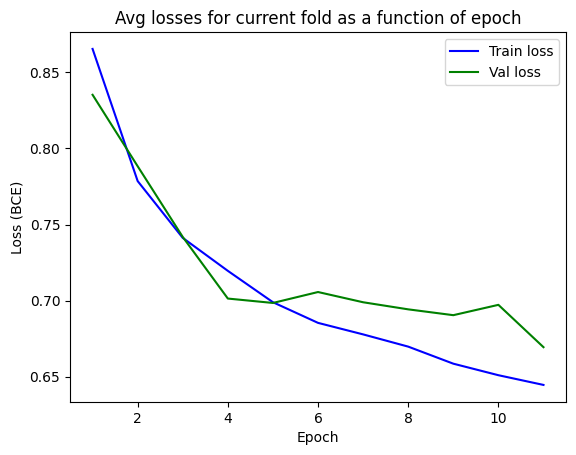

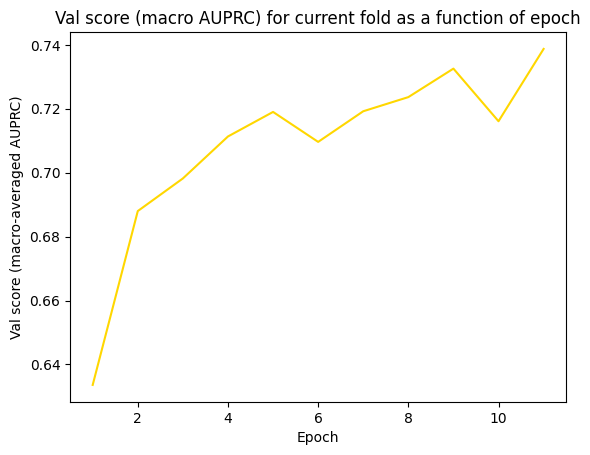

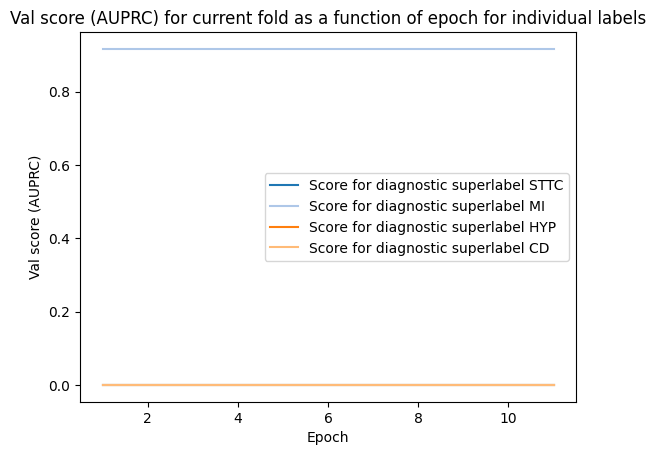

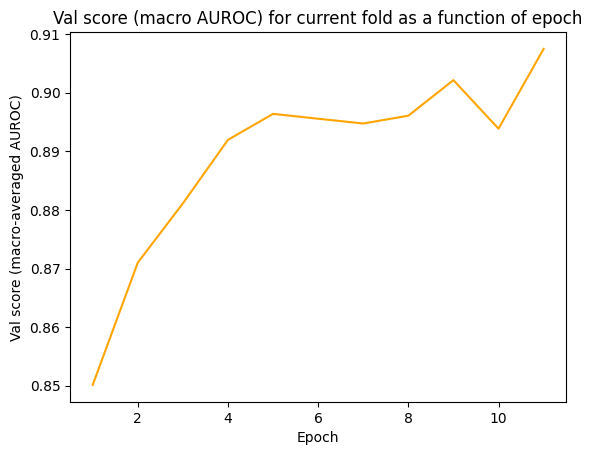

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


Finished epoch #  1. | Time elapsed during epoch:  1.763mins | Time since start:   1.775mins | Train avg loss =  0.865 | Val avg loss =  0.835 | Val score =  0.6336


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


Finished epoch #  2. | Time elapsed during epoch:  1.034mins | Time since start:   2.812mins | Train avg loss =  0.779 | Val avg loss =  0.788 | Val score =  0.6880


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


...

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


Finished epoch # 10. | Time elapsed during epoch:  1.635mins | Time since start:  14.334mins | Train avg loss =  0.651 | Val avg loss =  0.697 | Val score =  0.7161


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


Finished epoch # 11. | Time elapsed during epoch:  2.223mins | Time since start:  16.561mins | Train avg loss =  0.645 | Val avg loss =  0.669 | Val score =  0.7387


KeyboardInterrupt: 

In [10]:
FULL_TRAINING_LOOP() if DOING_TRAINING else None

## Save checkpoint, prepare for part III, etc.

We save the model weights from the best-performing model (the one from the epoch in which the model had the best validation score), as well as its feature embeddings of (i.e., the output of its feature extraction "bottom" portion on) all of the dataset, for later use in Part III below.

(Again, if the relevant switches are turned off, then these parts will be skipped.)

In [ ]:

from datetime import datetime



# Save the model that had the best macro AUPRC score

try:
    running_best_model
# Use model itself if no running_best_model has been assigned
except NameError: # running_best_model hasn't been defined yet. Only happens if cells were skipped
    running_best_model = model 
else:
    if running_best_model is None : # this should happen if eg no training was done
        running_best_model = model

# Put the best model in eval mode to "freeze" it
running_best_model.eval()


# Save best model's checkpoint

if SAVE_CHECKPOINT_AFTER_TRAINING :
    checkpoint = {
        'num_epochs_completed': running_best_model._num_epochs,
        'model_state': running_best_model.state_dict(),
        # 'optimizer_state': ... ,
    }
    timestamp = datetime.now().strftime("%Y-%m-%d %H..%M..%S")
    # torch.save(checkpoint, 'Data/Checkpoint/checkpoint.pth') # save without timestamp in filename
    torch.save(checkpoint, f'Data/Checkpoint/checkpoint {timestamp}.pth') # save with timestamp in filename
else :
    print("Did not save checkpoint because SAVE_CHECKPOINT_AFTER_TRAINING is set to False.")


# Save best model's feature embeddings and/or load them

if CALCULATE_FEATURE_EMBS :
    phi_x_np = np.zeros((Num_signals,256))
    with torch.no_grad():
        for i in range(Num_signals) :
            if i % 100 == 0 :
                print(f"Have finished preprocessing {i} of {Num_signals} signals.")
            x,y = full_dataset.__getitem__(i)
            x = x.unsqueeze(0).to(device)
            phi_x_np[i,:] = running_best_model.feature_extraction(x) .detach().cpu().numpy()
    print(f"Have finished preprocessing all {Num_signals} signals.")
    np.save('Data/Postprocessed/feature_embs_from_best_base_model-npy.npy', phi_x_np)
else:
    phi_x_np = np.load('Data/Postprocessed/feature_embs_from_best_base_model-npy.npy')

phi_x_df = pd.DataFrame(phi_x_np)
phi_x_df['y'] = ptbxl_annot_data['y_superclasses']


# III. Model selection experiment: comparing different classifier heads on top of the pre-trained feature extractor

In this section we do an experiment in which we try replacing the dense classifier head of the base model from earlier with other non-deep classifier heads, and compare all of these models' performances (including the original base model). 

| Model name | Type of classifier head used                     |
| ---------- | ------------------------------------------------ |
| A          | (original base model with deep classifier head)  |
| B          | logistic regressor                               |
| C          | KNN classifier                                   |
| D          | decision tree classifier                         |
| E          | SVC                                              |
| F          | random forest classifier                         |


In [ ]:
# First, in this cell we'll write a wrapper to use our existing base model's dense-layer classifier head, which was built using pytorch,  
# as one of the classifier head models we'll compare using sklearn.

# The dense classifier head will be from the best-performing-model from the training run above.
# However, it will be "frozen", i.e. its weights are now held fixed and the dense classifier doesn't learn further.


from sklearn.base import BaseEstimator, ClassifierMixin


class WrappedFrozenTorchClassifier( ClassifierMixin, BaseEstimator ):

    def __init__(
        self ,
        full_base_model : ECG_Classifier = running_best_model ,
        device = device ,
        batch_size = BATCH_SIZE,
        pred_threshold = DECISION_THRESHOLD_FOR_HARD_PRED
    ):
        self.full_base_model = full_base_model
        self.device = device
        self.batch_size = batch_size
        self.pred_threshold = pred_threshold

    def fit(self, X, y):
        # No training is performed! We only prepare the frozen torch model and set sklearn's fitted attributes.

        # Using "self.full_base_model_" to denote post-fitting self.full_base_model, etc, to match sklearn convention. 
        # (However, the distinction is artificial.)
        
        self.full_base_model_ = self.full_base_model.to(self.device)
        self.full_base_model_.eval()

        for parameter in self.full_base_model_.parameters():
            parameter.requires_grad_(False)

        self.n_features_in_ = X.shape[1]

        # For multilabel indicator targets such as shape (N, 4)
        self.n_outputs_ = y.shape[1]
        self.classes_ = np.arange(self.n_outputs_)

        return self
        

    def _logits(self, X):

        outputs = []

        self.full_base_model_.eval()

        with torch.inference_mode():
            output = self.full_base_model_.classifier_head( 
                torch.tensor(X, dtype=torch.float32).to(device)
            )

        return output

    

    def predict_proba(self, X):
        logits = self._logits(X)

        probabilities = torch.sigmoid(logits).cpu().numpy() # note: don't need detach() because the output from _logits() should already be from a model in inference mode

        return probabilities

    def predict(self, X):
        probabilities = self.predict_proba(X)

        if self.pred_threshold>0.0 :
            return (
                probabilities >= self.threshold_for_scoring
            ).astype(int)
        elif self.pred_threshold==0.0 :
            return (
                probabilities > 0.0
            ).astype(int)
            

    

In [ ]:
# In this cell we'll compare the val-set performance of all the models

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

import time

classifier_dict = {
    
    'A' : WrappedFrozenTorchClassifier() ,
    
    'B' : MultiOutputClassifier(
        LogisticRegression(max_iter=3000)
    ) ,
    
    # 'B2': Pipeline([
    #     ('ss',StandardScaler()) ,
    #     ('poly', PolynomialFeatures(degree=2,include_bias=False)) ,
    #     ('clf', MultiOutputClassifier( LogisticRegression(max_iter=3000) )) ,
    # ]) ,
    
    'C' : Pipeline([('ss',StandardScaler()),('knn', KNeighborsClassifier())]) ,
    
    'D' : DecisionTreeClassifier(
        # performance with default parameters was considerably worse and slower,
        # but improved with the below parameters. However, Model D is still in the bottom 2 out of 5.
        max_depth=10,
        min_samples_leaf=5,
        min_samples_split=5,
    ) ,
    
    'E' : MultiOutputClassifier( 
        SVC(kernel='rbf', C=1.0, gamma='scale') 
    ) ,

    'F' : RandomForestClassifier(n_estimators=100, random_state=42) ,
    
}




# Using folds 1-8 as train set, and fold 10 as test set.
# We already technically used fold 9 in selecting model A, so 
# using fold 10 as the test set now will prevent leakage.

train_idxlist = []
for i in range(8) : # folds 1-8
    train_idxlist.extend( fold_idxlists[i] )
val_idxlist = fold_idxlists[9] # fold 10

X_full = phi_x_np
y_full = np.stack(ptbxl_annot_data['y_superclasses'].to_numpy())
y_full[ y_full == -1.0 ] = 0.10 # encoding "unknown" confidence as this
X_train = X_full[ train_idxlist  , : ]
y_train = y_full[ train_idxlist  , : ]
X_val = X_full[ val_idxlist  , : ]
y_val = y_full[ val_idxlist  , : ]


# Need hard binary targets
if DECISION_THRESHOLD_FOR_TARGET_IN_SCORING > 0.0 :
    y_train_hard = np.where( y_train >= DECISION_THRESHOLD_FOR_TARGET_IN_SCORING , 1.0 , 0.0 )
    y_val_scoring = np.where( y_val >= DECISION_THRESHOLD_FOR_TARGET_IN_SCORING , 1.0 , 0.0 )
elif DECISION_THRESHOLD_FOR_TARGET_IN_SCORING == 0.0 : 
    y_val_scoring = np.where( y_val > 0.0 , 1.0 , 0.0 )
    y_train_hard = np.where( y_train > 0.0 , 1.0 , 0.0 )

results_dict = {
    'model' : [] ,
    'auprc' : [] ,
    'auroc' : [] ,
}
for letter,model in classifier_dict.items() :

    time_start = time.time()

    if letter=='A' :
        y_train_to_use = y_train
    else :
        # For the sklearn models, we need to use hard 0-or-1 training targets
        y_train_to_use = y_train_hard

    # Train/fit

    model.fit(X_train,y_train_to_use)

    # Get val-set predictions

    if letter=='E' :
        y_pred = np.column_stack([
            estimator.decision_function(X_val)
            for estimator in model.estimators_
        ])
    else :
        proba_list = model.predict_proba(X_val) # using predict_proba instead of predict because we want to use the continuous-valued output for scoring
        if letter=='A' :
            y_pred = proba_list
        else : 
            # For the sklearn models, we need to isolate the positive-class probabilities and drop the negative-class probabilities
            y_pred = np.column_stack([ proba[:, 1] for proba in proba_list ])

    # Get scores
    
    results_dict['model'].append(letter)
    
    macro_auprc = auprc(y_val_scoring, y_pred, average='macro')
    results_dict['auprc'].append(macro_auprc)
    
    macro_auroc = auroc(y_val_scoring, y_pred, average='macro')
    results_dict['auroc'].append(macro_auroc)

    time_now = time.time()
    print(f"Finished validating model {letter}.", end=' ')
    print(f"Time elapsed: {(time_now-time_start) : .3f}s")



print("\nValidation score results:")
print( pd.DataFrame(results_dict).set_index('model').to_string() )




## Results

Interestingly, Model B outperforms the original "fully deep" Model A. This suggests that the original model's dense classifier head may be overfitting to some extent, and the feature extractor is already capable of converting the diagnosis detection problem into a linearly separable one that can be handled by logistic regression.

In [ ]:
# Log the results in a csv file

with open("Results from different classifier heads for different num_layers.csv", "a") as file:
    for m in ['A','B','F'] :
        file.write(f"{NUM_LAYERS_IN_DENSE_CLASSIFIER_HEAD},{m},{ 
            results_dict['auprc'][ list(classifier_dict.keys()).index(m) ]
        }\n")
    